In [121]:
#> imports
import sys
import glob
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#> module impots (adding opus)
sys.path.insert(1, '../../opus/')
import plot
import lensing
import modules.geometry as geometry

### ***How Grid Resolution Effects Image Position Accuracy***
---


In [122]:
#> loading data
data_dir = '../data/simple_lenses/'
pattern = '*images*'
files = list(Path(data_dir).rglob(pattern))
files = [str(x).replace('\\','/') for x in files]

#> print
print(f'> The images files in {data_dir} are:')
[print(x) for x in files]

#> sorting by nph (highest first = reference)
files = sorted(files, key=lambda x: int(x.split('_')[3][3:]), reverse=True)

#> getting range of nphs
nphs = [int(x.split('_')[3][3:]) for x in files]

#> loading all data
images = []
for file in files:
    images.append(np.load(file, allow_pickle=True))
images = np.array(images, dtype=object)

> The images files in ../data/simple_lenses/ are:
../data/simple_lenses/26093016124901_nph250/26093016124901_nph250_images.npy
../data/simple_lenses/26093016272001_nph200/26093016272001_nph200_images.npy
../data/simple_lenses/26093016490706_nph150/26093016490706_nph150_images.npy
../data/simple_lenses/26093017014507_nph100/26093017014507_nph100_images.npy
../data/simple_lenses/26093017035409_nph50/26093017035409_nph50_images.npy


In [123]:
#> declarations
numNphs  = images.shape[0]
numQuads = images.shape[1]

#> iterating thru each quad
im_diff, num_found = [], []
for i in range(numQuads):
    
    #> reference images (highest nph); dropping nan rows
    ref_ims = np.asarray(images[0,i], dtype=float)
    ref_ims = ref_ims[~np.isnan(ref_ims).any(axis=1)]
    
    #> iterating thru each nph
    dummy, found = [], []
    for j in range(numNphs):
        
        #> images at this nph; dropping nan rows
        ims = np.asarray(images[j,i], dtype=float)
        ims = ims[~np.isnan(ims).any(axis=1)]
        found.append(len(ims))
        
        #> if either has no images, cannot compare
        if len(ims) == 0 or len(ref_ims) == 0: 
            dummy.append([np.nan, np.nan, np.nan])
            continue
        
        #> matching images by nearest neighbour (2D offset)
        dist = np.hypot(*(ims[:,None,:] - ref_ims[None,:,:]).transpose(2,0,1))
        diff = dist.min(axis=1)
        dummy.append([np.min(diff), np.mean(diff), np.max(diff)])

    #> appending
    im_diff.append(dummy)
    num_found.append(found)

#> converting
im_diff   = np.array(im_diff)    # (numQuads, numNphs, 3) [arcsec]
num_found = np.array(num_found)  # (numQuads, numNphs)

In [124]:
#> comparing nphs
for i in range(numNphs):

    #> getting full stats
    nph_stats = np.array([np.nanmin(im_diff[:,i,0]), np.nanmean(im_diff[:,i,1]), np.nanmax(im_diff[:,i,2])])
    num_full  = np.sum(num_found[:,i] == 5) # quads w/ all 5 images

    #> printing
    print(f'> For nph={nphs[i]}, (Min, Mean, Max)={nph_stats}, full quads = {num_full}/{numQuads}')

> For nph=250, (Min, Mean, Max)=[0. 0. 0.], full quads = 10000/10000
> For nph=200, (Min, Mean, Max)=[4.37526786e-08 1.19167895e-04 6.99626277e-03], full quads = 9999/10000
> For nph=150, (Min, Mean, Max)=[1.27421888e-07 2.70513301e-04 2.29554465e-02], full quads = 9996/10000
> For nph=100, (Min, Mean, Max)=[3.15253659e-07 6.75982804e-04 3.49216527e-02], full quads = 9985/10000
> For nph=50, (Min, Mean, Max)=[1.94469404e-06 2.58788479e-03 1.09342244e-01], full quads = 9897/10000


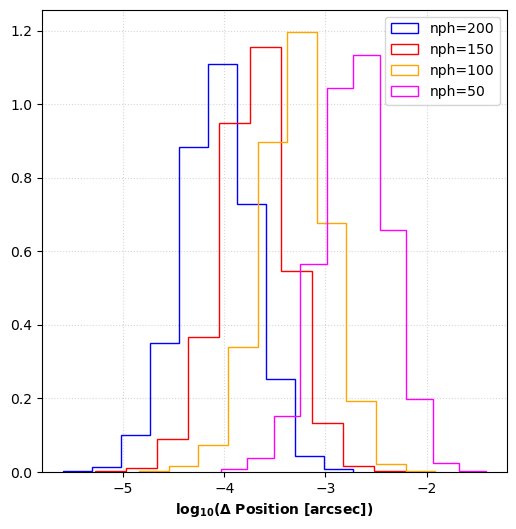

In [132]:
#> initializing
fig, ax = plt.subplots(1,1,figsize=(6,6))
ax.grid(ls=':', alpha=0.5)
ax.set_xlabel(r'$\mathbf{log_{10}(\Delta ~Position ~[arcsec])}$')

#> plotting!
for i in range(numNphs):
    if i == 0: continue
    ax.hist(np.log10(im_diff[:,i,1]), histtype='step', density=True, label=f'nph={nphs[i]}')

plt.legend()
plt.show()